2026-03-28 22:15:42 - 01_hh_analysis - INFO - Ноутбук запущен


2026-03-28 22:15:42 - 01_hh_analysis - INFO - Загружено 13 навыков (competency_frequency)


2026-03-28 22:15:42 - 01_hh_analysis - INFO - Загружено 55 навыков с TF‑IDF весами


2026-03-28 22:15:42 - 01_hh_analysis - INFO - Загружен маппинг для 44 компетенций


Загружено 13 уникальных навыков с частотами.
Всего упоминаний: 18
Маппинг содержит 44 компетенций

Пример навыков и их частот:
git: 3
postgresql: 2
linux: 2
docker: 2
javascript: 1
node.js: 1
java: 1
redis: 1
rest api: 1
mysql: 1

Пример навыков и их TF‑IDF весов:
frontend: 0.1577
sql: 0.1114
postgresql: 0.1051
redis: 0.1031
docker: 0.1030
golang: 0.1021
git: 0.0940
linux: 0.0860
sql golang: 0.0838
api: 0.0791


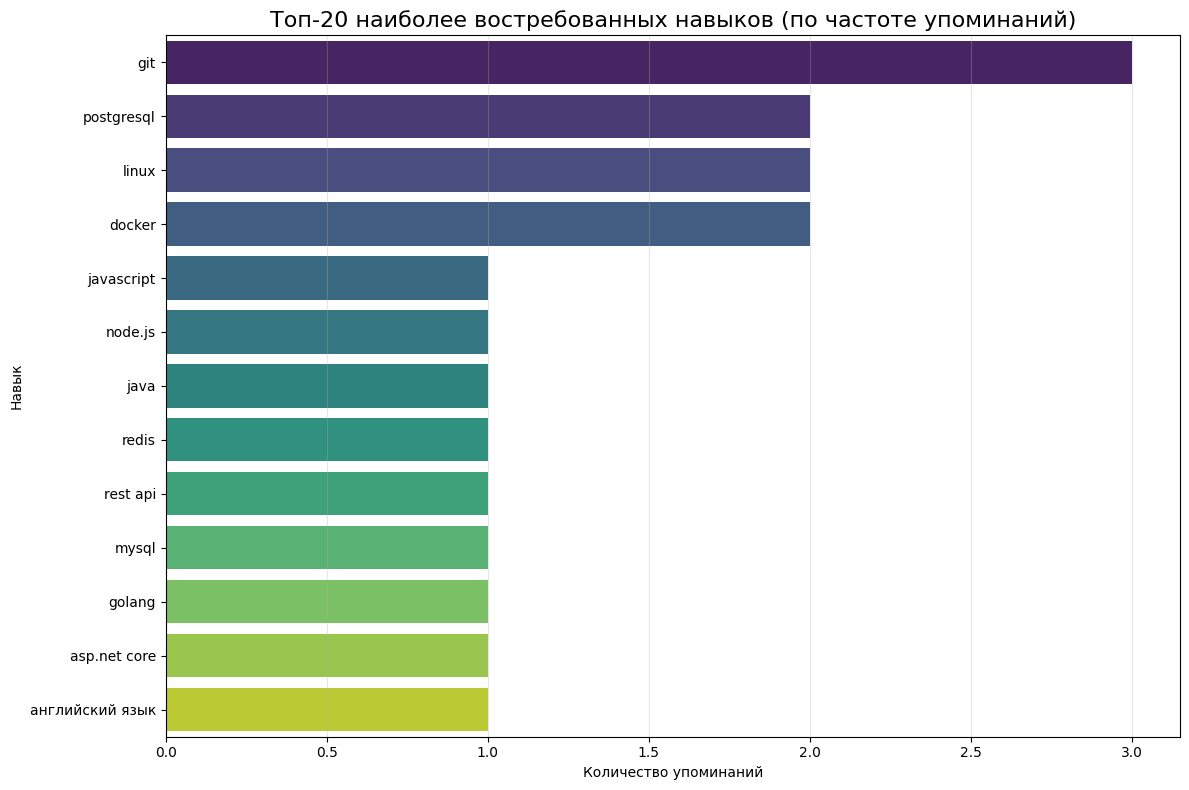

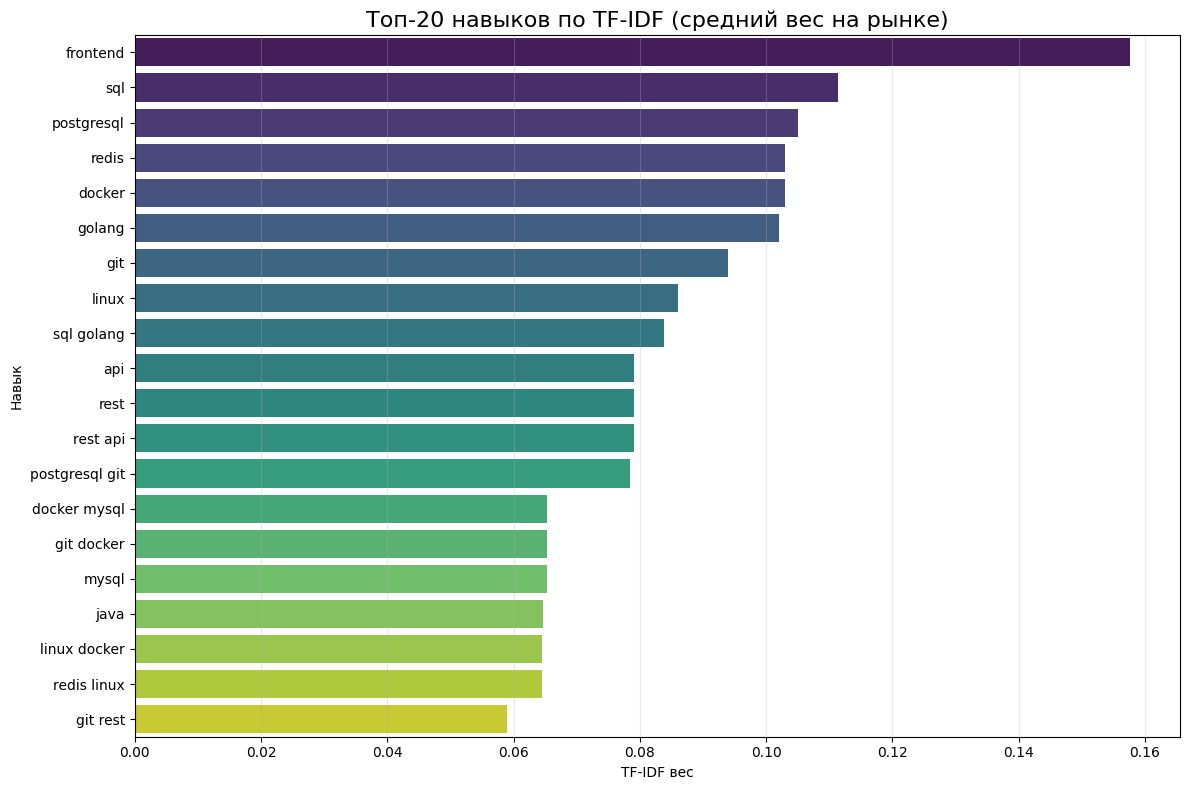

Успешно сопоставлено 3 учебных компетенций


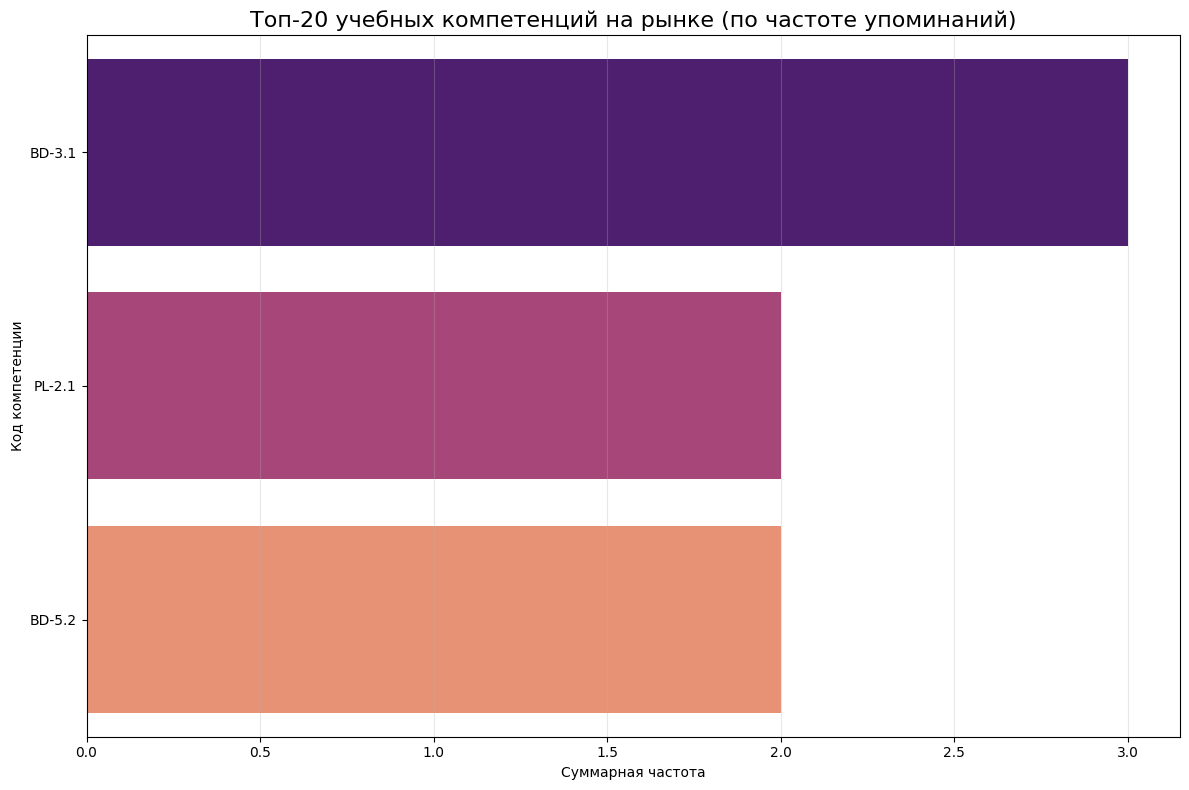

In [1]:
# %% [markdown]
# ### 1. Подготовка окружения
# %%
import sys
from pathlib import Path

# Определяем корень проекта (папка выше notebooks)
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from src.config import DATA_PROCESSED_DIR
from src.utils import get_logger, load_competency_mapping

logger = get_logger("01_hh_analysis")
logger.info("Ноутбук запущен")

# %% [markdown]
# ### 2. Загрузка данных

# %%
# Загружаем частоты навыков (старый формат)
freq_path = DATA_PROCESSED_DIR / "competency_frequency.json"
if not freq_path.exists():
    logger.error(f"Файл {freq_path} не найден. Сначала запустите main.py.")
    raise FileNotFoundError(f"Файл {freq_path} не найден")

with open(freq_path, 'r', encoding='utf-8') as f:
    skill_freq = json.load(f)
logger.info(f"Загружено {len(skill_freq)} навыков (competency_frequency)")

# Загружаем TF‑IDF веса, если есть
weights_path = DATA_PROCESSED_DIR / "skill_weights.json"
skill_weights = {}
if weights_path.exists():
    with open(weights_path, 'r', encoding='utf-8') as f:
        skill_weights = json.load(f)
    logger.info(f"Загружено {len(skill_weights)} навыков с TF‑IDF весами")
else:
    logger.warning("skill_weights.json не найден – будут использованы только частоты")

mapping = load_competency_mapping()
if not mapping:
    logger.warning("Маппинг компетенций пуст")
else:
    logger.info(f"Загружен маппинг для {len(mapping)} компетенций")

# %% [markdown]
# ### 3. Статистика и примеры навыков

# %%
total_mentions = sum(skill_freq.values())
unique_skills = len(skill_freq)

print(f"Загружено {unique_skills} уникальных навыков с частотами.")
print(f"Всего упоминаний: {total_mentions}")
print(f"Маппинг содержит {len(mapping)} компетенций\n")

print("Пример навыков и их частот:")
top_example = sorted(skill_freq.items(), key=lambda x: x[1], reverse=True)[:10]
for skill, count in top_example:
    print(f"{skill}: {count}")

if skill_weights:
    print("\nПример навыков и их TF‑IDF весов:")
    top_weights = sorted(skill_weights.items(), key=lambda x: x[1], reverse=True)[:10]
    for skill, weight in top_weights:
        print(f"{skill}: {weight:.4f}")

# %% [markdown]
# ### 4. Визуализация топ‑20 востребованных навыков

# %%
top_skills = sorted(skill_freq.items(), key=lambda x: x[1], reverse=True)[:20]
skills, counts = zip(*top_skills)

plt.figure(figsize=(12, 8))
sns.barplot(x=counts, y=skills, hue=skills, palette="viridis", legend=False)
plt.title("Топ‑20 наиболее востребованных навыков (по частоте упоминаний)", fontsize=16)
plt.xlabel("Количество упоминаний")
plt.ylabel("Навык")
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Если есть веса, покажем и их
if skill_weights:
    top_weighted = sorted(skill_weights.items(), key=lambda x: x[1], reverse=True)[:20]
    skills_w, weights = zip(*top_weighted)
    plt.figure(figsize=(12, 8))
    sns.barplot(x=weights, y=skills_w, hue=skills_w, palette="viridis", legend=False)
    plt.title("Топ‑20 навыков по TF‑IDF (средний вес на рынке)", fontsize=16)
    plt.xlabel("TF‑IDF вес")
    plt.ylabel("Навык")
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

# %% [markdown]
# ### 5. Топ учебных компетенций на рынке (после маппинга)

# %%
# Преобразуем рыночные навыки в учебные компетенции (используем частоты)
comp_counter = Counter()

for skill, freq in skill_freq.items():
    normalized_skill = skill.lower().strip()
    for comp_code, keywords in mapping.items():
        if any(kw.lower() in normalized_skill or normalized_skill in kw.lower() for kw in keywords):
            comp_counter[comp_code] += freq
            break   # каждый навык относим к одной компетенции

print(f"Успешно сопоставлено {len(comp_counter)} учебных компетенций")

# Топ‑20 компетенций
top_comp = comp_counter.most_common(20)
if top_comp:
    comp_names, comp_counts = zip(*top_comp)
    plt.figure(figsize=(12, 8))
    sns.barplot(x=comp_counts, y=comp_names, hue=comp_names, palette="magma", legend=False)
    plt.title("Топ‑20 учебных компетенций на рынке (по частоте упоминаний)", fontsize=16)
    plt.xlabel("Суммарная частота")
    plt.ylabel("Код компетенции")
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Нет сопоставленных компетенций – проверьте mapping.")